In [3]:
# 3 - modeling

# The purpose of this notebook is to store the current best model

# The best model code is found at the bottom of this notebook (model performance is seed dependent.
# The current model uses a seed of 3)


In [4]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import sys
import os
import importlib
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.data import load_images_from_metadata, filter_images

In [5]:
# load all of the data into metadata csv file including the new data (data_new_2))
from src.build_metadata import load_metadata
import importlib
import src.build_metadata as build_metadata

importlib.reload(build_metadata)
build_metadata.load_metadata(
    data_base_dir="../data",
    new_data_base_dir="../data_new",
    new_data_2_base_dir="../data_new_2",
    output_file="metadata.csv",
)

Applied human ratings to 851 DD rows.
Saved metadata to ../data\metadata.csv
Combined records: 1345


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
1340,5.8,Brooke,7.21.26,TEST,2BDR-9F02,25-143,flat,../data_test\{leveling-5.8}_P{Brooke}_D{7.21.2...
1341,6.3,Brooke,7.21.26,TEST,2BDR-9F02,25-141,flat,../data_test\{leveling-6.3}_P{Brooke}_D{7.21.2...
1342,6.8,Brooke,7.21.26,TEST,2BDR-9F02,25-104,flat,../data_test\{leveling-6.8}_P{Brooke}_D{7.21.2...
1343,8.0,Brooke,7.21.26,TEST,2BDR-9F02,25-125,flat,../data_test\{leveling-8.0}_P{Brooke}_D{7.21.2...


In [6]:
# get the data
data = load_images_from_metadata("../data/metadata.csv", crop_fraction = .4, use_cv2=True)

data_standards = filter_images(data, ImageType = "STD", State = "flat", DateCollected = ["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"])
data_real_paint = filter_images(data, ImageType = "DD", State = "flat")

Loaded 1345 images (cropping=ON, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


In [7]:
"""
'img_size': 92
num_blocks': 5
base_channels': 12
hidden_dim': 256
dropout': 0.2511572371061875
use_batchnorm': True
batch_size': 32
optimizer': 'Adam'
'lr': 0.0006049716507542575
'weight_decay': 1.963434157293331e-08
'rotation_deg': 6
'crop_scale': 0.9608106745617722
'loss': 'SmoothL1'
Best is trial 1 with value: 0.4067451059818268.
"""

"\n'img_size': 92\nnum_blocks': 5\nbase_channels': 12\nhidden_dim': 256\ndropout': 0.2511572371061875\nuse_batchnorm': True\nbatch_size': 32\noptimizer': 'Adam'\n'lr': 0.0006049716507542575\n'weight_decay': 1.963434157293331e-08\n'rotation_deg': 6\n'crop_scale': 0.9608106745617722\n'loss': 'SmoothL1'\nBest is trial 1 with value: 0.4067451059818268.\n"

In [8]:
# try with seed = 3

In [9]:
# nessary classes/ functions

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn as nn


def prepare_tensors(data, img_size=(64, 64)):
    X, y, groups = [], [], []
    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        if img.ndim != 2:
            raise ValueError(f"Expected grayscale 2D image, got shape {img.shape}")

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0),
            size=img_size,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)

        X.append(img)
        y.append(float(d["LevelingScore"]))
        groups.append(d.get("PanelID", None))

    return X, np.array(y, dtype=np.float32), np.array(groups)

def make_transforms(img_size, rotation_deg, crop_scale):
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(rotation_deg),
        transforms.RandomResizedCrop(
            img_size,
            scale=(crop_scale, 1.0),
            antialias=True,
        ),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    val_tf = transforms.Compose([
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    return train_tf, val_tf

class TensorListDataset(Dataset):
    def __init__(self, X_list, y_array, transform=None):
        self.X_list = X_list
        self.y_array = y_array
        self.transform = transform

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        x = self.X_list[idx].clone()
        if self.transform is not None:
            x = self.transform(x)
        y = torch.tensor(self.y_array[idx], dtype=torch.float32)
        return x, y

def weighted_sampler_from_y(y, seed=None):
    y_int = np.rint(y).astype(int)
    unique, counts = np.unique(y_int, return_counts=True)
    freq = {k: c for k, c in zip(unique, counts)}
    weights = np.array([1.0 / freq[v] for v in y_int], dtype=np.float32)

    generator = None
    if seed is not None:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return WeightedRandomSampler(
        torch.tensor(weights),
        num_samples=len(weights),
        replacement=True,
        generator=generator,
    )

class WaveletCNNRegressor(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16, hidden_dim=128, dropout=0.5, use_batchnorm=True):
        super().__init__()
        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels
        for i in range(num_blocks):
            layers.append(nn.Conv2d(in_channels, channels, 3, padding=1))
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(channels))
            layers.extend([
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU(),
            ])
            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2, 3])
        m1 = x_low1.mean(dim=[2, 3])
        m2 = x_low2.mean(dim=[2, 3])
        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)
        return self.regressor(combined).squeeze(1)

def make_optimizer(name, params, lr, weight_decay):
    if name == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "RMSprop":
        return optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)

def make_loss(name):
    if name == "L1":
        return nn.L1Loss()
    if name == "MSE":
        return nn.MSELoss()
    return nn.SmoothL1Loss(beta=0.5)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# model with fixed wavelet parameters: train on standards, evaluate on real paint, save final weights each run

import os
import random
from datetime import datetime
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader

# Ensure required objects from earlier cells exist
required_names = [
    "data_standards",
    "data_real_paint",
    "prepare_tensors",
    "make_transforms",
    "TensorListDataset",
    "weighted_sampler_from_y",
    "WaveletCNNRegressor",
    "make_optimizer",
    "make_loss",
    "DEVICE",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Run earlier setup cells first. Missing: {missing}")

# Randomize initialization every run (different seed each execution)
run_seed = 3
random.seed(run_seed)
np.random.seed(run_seed)
torch.manual_seed(run_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(run_seed)

# Fixed parameters you provided
fixed_p = {
    "img_size": 92,
    "num_blocks": 5,
    "base_channels": 12,
    "hidden_dim": 256,
    "dropout": 0.2511572371061875,
    "use_batchnorm": True,
    "batch_size": 32,
    "optimizer": "Adam",
    "lr": 0.0006049716507542575,
    "weight_decay": 1.963434157293331e-08,
    "rotation_deg": 6,
    "crop_scale": 0.9608106745617722,
    "loss": "SmoothL1",
}
epochs = 70

img_size = int(fixed_p["img_size"])
X_std, y_std, groups_std = prepare_tensors(data_standards, img_size=(img_size, img_size))
X_real, y_real, groups_real = prepare_tensors(data_real_paint, img_size=(img_size, img_size))

train_tf, test_tf = make_transforms(
    img_size=img_size,
    rotation_deg=int(fixed_p["rotation_deg"]),
    crop_scale=float(fixed_p["crop_scale"]),
)

# Train on all standards
std_train_ds = TensorListDataset(X_std, y_std, transform=train_tf)
std_sampler = weighted_sampler_from_y(y_std, seed=run_seed)
std_train_loader = DataLoader(
    std_train_ds,
    batch_size=int(fixed_p["batch_size"]),
    sampler=std_sampler,
    drop_last=False,
)

# Evaluate on all real paint
real_test_ds = TensorListDataset(X_real, y_real, transform=test_tf)
real_test_loader = DataLoader(
    real_test_ds,
    batch_size=int(fixed_p["batch_size"]),
    shuffle=False,
    drop_last=False,
)

model_fixed = WaveletCNNRegressor(
    num_blocks=int(fixed_p["num_blocks"]),
    base_channels=int(fixed_p["base_channels"]),
    hidden_dim=int(fixed_p["hidden_dim"]),
    dropout=float(fixed_p["dropout"]),
    use_batchnorm=bool(fixed_p["use_batchnorm"]),
).to(DEVICE)

optimizer_fixed = make_optimizer(
    fixed_p["optimizer"],
    model_fixed.parameters(),
    float(fixed_p["lr"]),
    float(fixed_p["weight_decay"]),
)
criterion_fixed = make_loss(fixed_p["loss"])

print("=" * 76)
print("FIXED-PARAM WAVELET MODEL | TRAIN: STANDARDS (70 EPOCHS) | TEST: REAL PAINT")
print("Random initialization enabled: new seed per run")
print("=" * 76)
print(f"Run seed: {run_seed}")
print(f"Standards train size: {len(X_std)} | Real-paint test size: {len(X_real)}")

for epoch in range(epochs):
    model_fixed.train()
    running_loss = 0.0
    n_seen = 0

    for images, labels in std_train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_fixed.zero_grad()
        preds = model_fixed(images)
        loss = criterion_fixed(preds, labels)
        loss.backward()
        optimizer_fixed.step()

        batch_n = images.size(0)
        running_loss += loss.item() * batch_n
        n_seen += batch_n

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch + 1}/{epochs} - train loss: {running_loss / max(1, n_seen):.4f}")

# Inference on real paint
model_fixed.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for images, labels in real_test_loader:
        images = images.to(DEVICE)
        preds = model_fixed(images)
        preds_all.append(preds.detach().cpu().numpy())
        labels_all.append(labels.numpy())

preds_np = np.concatenate(preds_all)
labels_np = np.concatenate(labels_all)
abs_err = np.abs(preds_np - labels_np)

print("\nReal-paint evaluation (raw, no calibration):")
print(f"  MAE: {float(abs_err.mean()):.4f}")
print(f"  Within +/-1: {float((abs_err <= 1).mean() * 100):.2f}%")
print(f"  Within +/-2: {float((abs_err <= 2).mean() * 100):.2f}%")
print(f"  Within +/-3: {float((abs_err <= 3).mean() * 100):.2f}%")
print(f"  Within +/-4: {float((abs_err <= 4).mean() * 100):.2f}%")

results_real_fixed_df = pd.DataFrame(
    {
        "PanelID": groups_real,
        "Prediction": preds_np,
        "TrueLabel": labels_np,
    }
)
results_real_fixed_df["Difference"] = results_real_fixed_df["Prediction"] - results_real_fixed_df["TrueLabel"]
results_real_fixed_df["AbsDifference"] = np.abs(results_real_fixed_df["Difference"])

print("\nPreview:")
display(results_real_fixed_df.head(20))

# Save final model weights and run metadata
os.makedirs("../models", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = f"../models/wavelet_fixed_standards_to_real_e70_seed{run_seed}_{timestamp}.pt"

checkpoint = {
    "model_state_dict": model_fixed.state_dict(),
    "params": fixed_p,
    "epochs": epochs,
    "run_seed": run_seed,
    "metrics": {
        "mae": float(abs_err.mean()),
        "within_1": float((abs_err <= 1).mean() * 100),
        "within_2": float((abs_err <= 2).mean() * 100),
        "within_3": float((abs_err <= 3).mean() * 100),
        "within_4": float((abs_err <= 4).mean() * 100),
    },
}
torch.save(checkpoint, save_path)
print(f"\nSaved final model checkpoint to: {save_path}")

FIXED-PARAM WAVELET MODEL | TRAIN: STANDARDS (70 EPOCHS) | TEST: REAL PAINT
Random initialization enabled: new seed per run
Run seed: 3
Standards train size: 177 | Real-paint test size: 430
  Epoch 1/70 - train loss: 3.8307
  Epoch 10/70 - train loss: 0.7351
  Epoch 20/70 - train loss: 0.5065
  Epoch 30/70 - train loss: 0.4607
  Epoch 40/70 - train loss: 0.6680
  Epoch 50/70 - train loss: 0.5637
  Epoch 60/70 - train loss: 0.4271
  Epoch 70/70 - train loss: 0.5344

Real-paint evaluation (raw, no calibration):
  MAE: 0.6798
  Within +/-1: 79.07%
  Within +/-2: 96.74%
  Within +/-3: 99.30%
  Within +/-4: 100.00%

Preview:


,PanelID,Prediction,TrueLabel,Difference,AbsDifference
0,25-130,1.856636,1.3,0.556636,0.556636
1,25-130,1.732070,1.3,0.432070,0.432070
2,25-130,1.407076,1.3,0.107076,0.107076
3,25-130,1.696472,1.3,0.396472,0.396472
4,25-130,1.975164,1.3,0.675164,0.675164
5,25-130,1.679193,1.3,0.379193,0.379193
6,25-101,3.155988,2.2,0.955988,0.955988
7,25-101,2.841805,2.2,0.641805,0.641805
8,25-101,2.895194,2.2,0.695194,0.695194
9,25-101,2.765134,2.2,0.565134,0.565134



Saved final model checkpoint to: ../models/wavelet_fixed_standards_to_real_e70_seed3_20260731_114335.pt


In [11]:
# report c-index 

def c_index(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    n = len(y_true)
    if n < 2:
        return np.nan, 0

    concordant = 0.0
    comparable = 0

    for i in range(n - 1):
        dy = y_true[i + 1:] - y_true[i]
        dp = y_pred[i + 1:] - y_pred[i]

        mask = dy != 0
        if not np.any(mask):
            continue

        dy = dy[mask]
        dp = dp[mask]

        comparable += dy.size
        concordant += np.sum((dy * dp) > 0)
        concordant += 0.5 * np.sum(dp == 0)

    if comparable == 0:
        return np.nan, 0
    return concordant / comparable, comparable


# Image-level C-index
c_img, n_img_pairs = c_index(labels_np, preds_np)

# Panel-level C-index
panel_df = (
    pd.DataFrame({"PanelID": groups_real, "TrueLabel": labels_np, "Pred": preds_np})
    .groupby("PanelID", dropna=False)
    .agg(TrueLabel=("TrueLabel", "mean"), Pred=("Pred", "mean"))
    .reset_index()
)
c_panel, n_panel_pairs = c_index(panel_df["TrueLabel"].values, panel_df["Pred"].values)

print("\nC-index (real paint, no calibration):")
print(f"  Image-level C-index: {c_img:.4f} (comparable pairs: {n_img_pairs})")
print(f"  Panel-level C-index: {c_panel:.4f} (comparable pairs: {n_panel_pairs})")


C-index (real paint, no calibration):
  Image-level C-index: 0.8970 (comparable pairs: 87990)
  Panel-level C-index: 0.8921 (comparable pairs: 1298)


In [12]:
# panel level std

panel_std = (
pd.DataFrame({"PanelID": groups_real, "Pred": preds_np, "True": labels_np})
.assign(Err=lambda d: d["Pred"] - d["True"])
.groupby("PanelID", dropna=False)
.agg(
PredStd=("Pred", lambda s: s.std(ddof=0)),
TrueStd=("True", lambda s: s.std(ddof=0)),
ErrStd=("Err", lambda s: s.std(ddof=0)),
)
.fillna(0.0)
.sort_index()
)

print("Average std across panels:")
print(panel_std.mean(numeric_only=True).to_string(float_format=lambda x: f"{x:.4f}"))

print("\nStd for each panel:")
print(panel_std.to_string(float_format=lambda x: f"{x:.4f}"))

Average std across panels:
PredStd   0.3111
TrueStd   0.0000
ErrStd    0.3111

Std for each panel:
         PredStd  TrueStd  ErrStd
PanelID                          
25-100    0.2740   0.0000  0.2740
25-101    0.4322   0.0000  0.4322
25-102    0.1019   0.0000  0.1019
25-103    0.2010   0.0000  0.2010
25-104    0.1864   0.0000  0.1864
25-105    0.2398   0.0000  0.2398
25-106    0.1409   0.0000  0.1409
25-107    0.6566   0.0000  0.6566
25-108    0.2765   0.0000  0.2765
25-109    0.2217   0.0000  0.2217
25-110    0.4604   0.0000  0.4604
25-111    0.3784   0.0000  0.3784
25-112    0.0797   0.0000  0.0797
25-113    0.6056   0.0000  0.6056
25-114    0.1294   0.0000  0.1294
25-115    0.7201   0.0000  0.7201
25-116    0.2206   0.0000  0.2206
25-117    0.1330   0.0000  0.1330
25-118    0.1246   0.0000  0.1246
25-119    0.1311   0.0000  0.1311
25-120    0.2140   0.0000  0.2140
25-121    0.1591   0.0000  0.1591
25-122    0.1235   0.0000  0.1235
25-123    0.1053   0.0000  0.1053
25-124    0.2244 

In [13]:
# print out the top 20 worst model predictions (by absolute error)

worst20 = (
    pd.DataFrame({"PanelID": groups_real, "Prediction": preds_np, "TrueLabel": labels_np})
    .assign(
        Difference=lambda d: d["Prediction"] - d["TrueLabel"],
        AbsDifference=lambda d: (d["Prediction"] - d["TrueLabel"]).abs(),
    )
    .sort_values("AbsDifference", ascending=False)
    .head(20)
)

print(worst20[["PanelID", "Prediction", "TrueLabel", "Difference", "AbsDifference"]].to_string(index=False))

PanelID  Prediction  TrueLabel  Difference  AbsDifference
 25-150    8.157656        5.0    3.157656       3.157656
 25-145    7.296235        4.2    3.096235       3.096235
 25-145    7.241970        4.2    3.041970       3.041970
 25-145    7.182578        4.2    2.982578       2.982578
 25-128   10.013325        7.2    2.813325       2.813325
 25-150    7.402341        5.0    2.402341       2.402341
 25-146    8.692868        6.3    2.392868       2.392868
 25-133    6.833534        4.5    2.333534       2.333534
 25-150    7.093002        5.0    2.093002       2.093002
 25-145    6.272435        4.2    2.072435       2.072435
 25-115    7.260565        5.2    2.060565       2.060565
 25-145    6.256768        4.2    2.056768       2.056768
 25-133    6.537483        4.5    2.037483       2.037483
 25-128    9.210763        7.2    2.010763       2.010763
 25-146    8.264338        6.3    1.964337       1.964337
 25-146    8.252191        6.3    1.952190       1.952190
 25-107    9.0

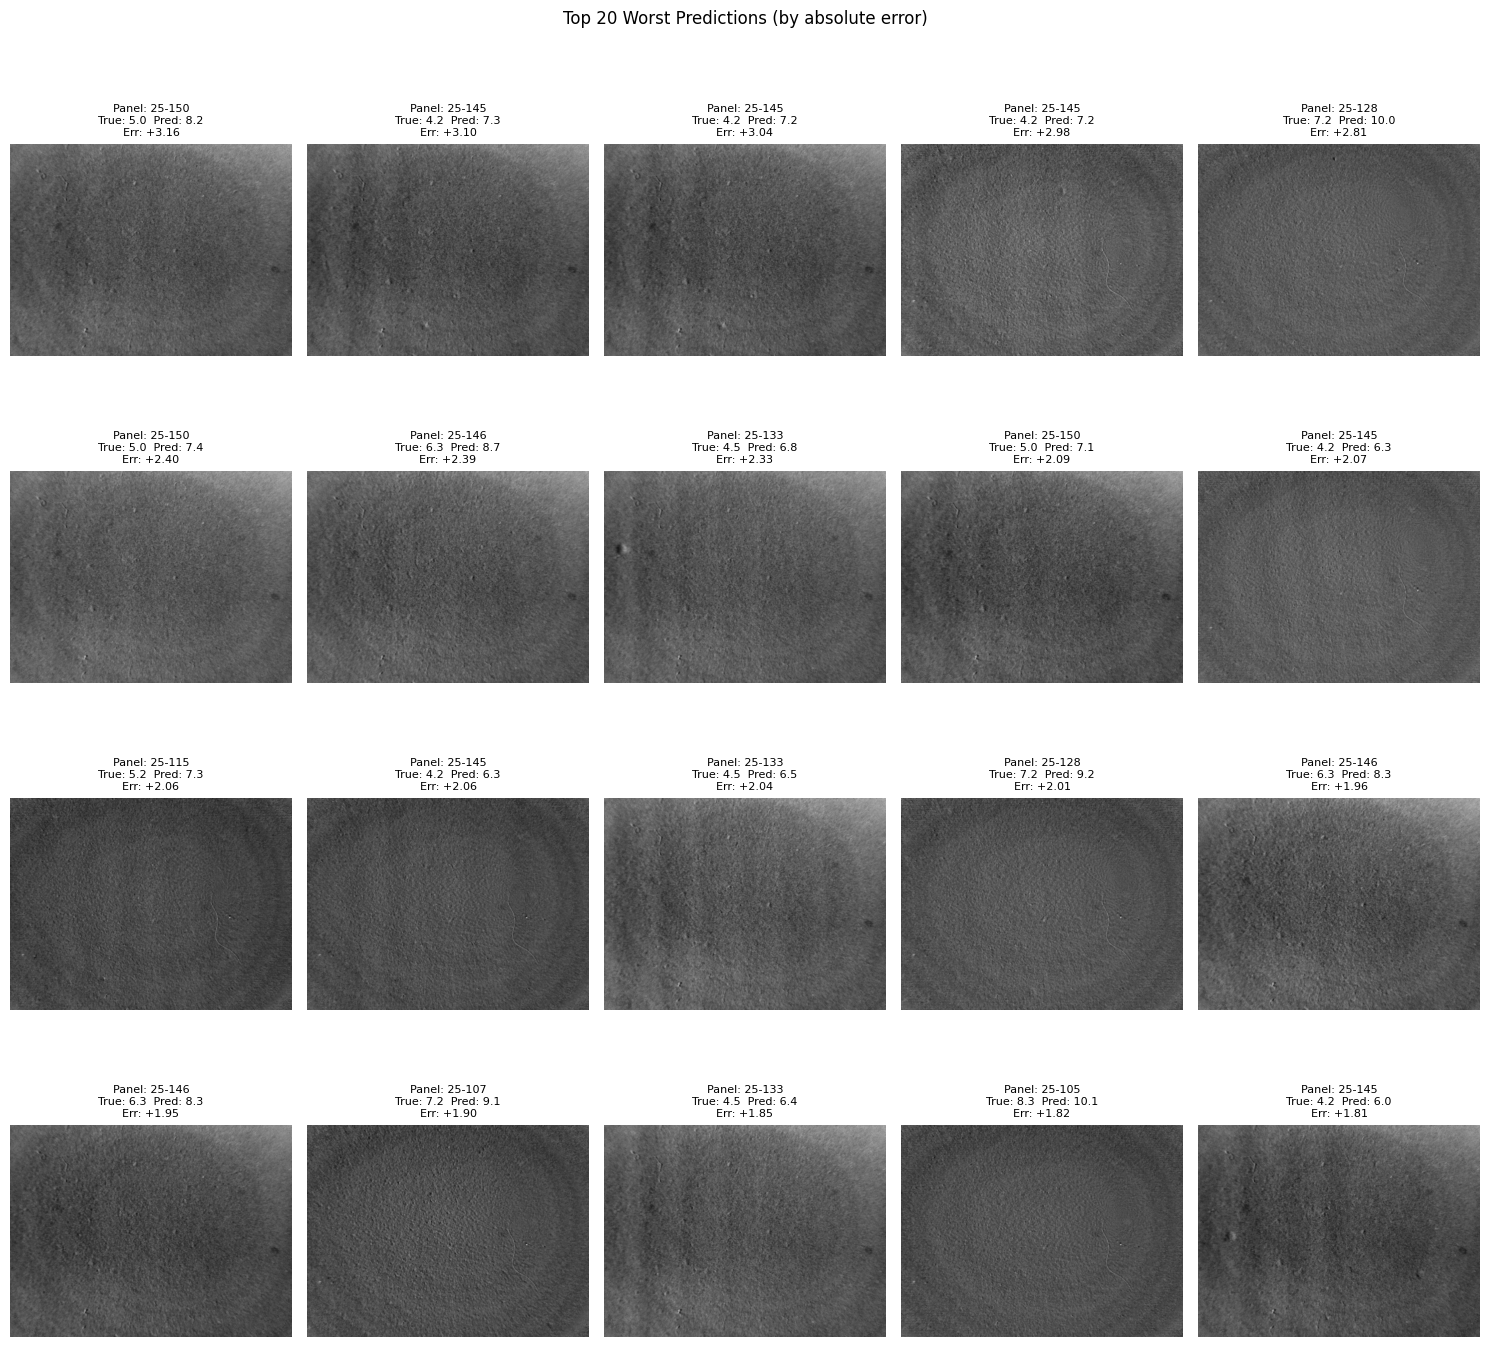

In [14]:

import matplotlib.pyplot as plt
import math

worst20_idx = (
    pd.DataFrame({
        "idx": range(len(groups_real)),
        "PanelID": groups_real,
        "Prediction": preds_np,
        "TrueLabel": labels_np,
    })
    .assign(AbsDifference=lambda d: (d["Prediction"] - d["TrueLabel"]).abs())
    .sort_values("AbsDifference", ascending=False)
    .head(20)
)

n = len(worst20_idx)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.5))
axes = axes.flatten()

for ax_i, (_, row) in enumerate(worst20_idx.iterrows()):
    img = data_real_paint[int(row["idx"])]["image"]
    axes[ax_i].imshow(img, cmap="gray")
    axes[ax_i].set_title(
        f"Panel: {row['PanelID']}\nTrue: {row['TrueLabel']:.1f}  Pred: {row['Prediction']:.1f}\nErr: {row['Prediction'] - row['TrueLabel']:+.2f}",
        fontsize=8,
    )
    axes[ax_i].axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Top 20 Worst Predictions (by absolute error)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


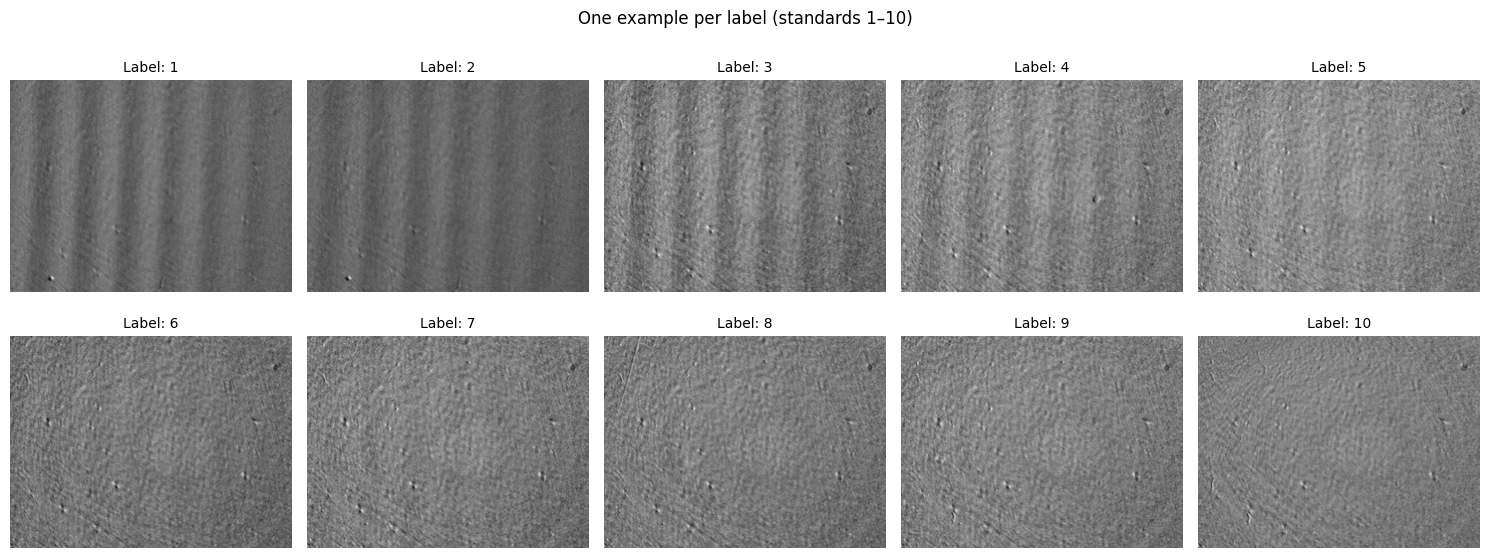

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for score in range(1, 11):
    match = next((d for d in data_standards if int(d["LevelingScore"]) == score), None)
    ax = axes[score - 1]
    if match is not None:
        ax.imshow(match["image"], cmap="gray")
        ax.set_title(f"Label: {score}", fontsize=10)
    else:
        ax.set_title(f"Label: {score}\n(no sample)", fontsize=10)
    ax.axis("off")

plt.suptitle("One example per label (standards 1–10)", fontsize=12)
plt.tight_layout()
plt.show()


In [21]:
# make inference on a sample 

image_path = r"C:\Users\bxb370\GelSiteMiniFlowAndLevelingModel\data_test\{leveling-2.5}_P{Brooke}_D{7.21.26}_type{TEST}_GS{2BDR-9F02}_Panel{GS-25-103}_0degrees_flat.png"

import cv2
import torch
import numpy as np

# Load raw grayscale image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(image_path)

print(f"Image shape: {img.shape}")

# Convert to float32 and normalize
img = img.astype(np.float32) / 255.0

# Crop 20% from each side (crop_fraction=0.4)
img = img[492:1972, 656:2624]

# Convert to tensor and resize to training size
img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
img_size = int(fixed_p["img_size"])
img_tensor = torch.nn.functional.interpolate(
    img_tensor,
    size=(img_size, img_size),
    mode="bilinear",
    align_corners=False
)

# Normalize (mean=0.5, std=0.5)
img_tensor = (img_tensor - 0.5) / 0.5

# Run inference
model_fixed.eval()
with torch.no_grad():
    prediction = model_fixed(img_tensor.to(DEVICE)).item()

print(f"Predicted Leveling Score: {prediction:.3f}")

Image shape: (2464, 3280)
Predicted Leveling Score: 3.079
